# Tutorial 5 — RDKit Essentials: From SMILES to Insights
**Author:** Himanshu Goel 

RDKit is the cornerstone of modern cheminformatics. This comprehensive tutorial takes you from basic molecule loading to advanced analysis techniques. You'll learn to handle molecular data, compute properties, visualize structures, and perform substructure searches — everything you need for drug discovery and chemical analysis.

**What you'll learn:**
- Loading molecules from various formats (SMILES, InChI, SDF)
- Computing physicochemical descriptors and fingerprints
- 2D and 3D molecular visualization
- Substructure and similarity searching
- Structure generation and conformer analysis
- Exporting data in multiple formats

In [33]:
# Install RDKit and dependencies
# RDKit: Core cheminformatics library
# pandas: Data manipulation
# numpy: Numerical computing
# matplotlib: Plotting and visualization
# pillow: Image processing
# seaborn: Statistical visualization
!pip install rdkit pandas numpy matplotlib pillow seaborn scikit-learn -q

In [35]:
# ============================================================================
# IMPORTS AND SETUP
# ============================================================================

# Core RDKit functionality
from rdkit import Chem
from rdkit.Chem import (
    Draw,           # 2D molecular drawing
    Descriptors,    # Molecular descriptors
    rdMolDescriptors,  # Advanced descriptors
    AllChem,       # General chemistry functions
    rdDepictor,    # Depiction algorithms
    rdFingerprintGenerator  # Fingerprint generation
)

# Additional RDKit modules
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.inchi import MolFromInchi, MolToInchi
from rdkit.Chem.MolStandardize import rdMolStandardize

# Data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Display and image handling
from IPython.display import display, Image, HTML, Markdown
from PIL import Image as PILImage
import io

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"RDKit version: {Chem.rdBase.rdkitVersion}")

✅ All libraries imported successfully!
RDKit version: 2025.09.3


In [36]:
# Demonstrate basic operations
print("\n🔧 Basic molecular operations...")
# Remove hydrogens and add them back (demonstrates hydrogen handling)
mol_no_h = Chem.RemoveHs(mol)
mol_with_h = Chem.AddHs(mol_no_h)
print(f"✅ Hydrogen handling: {mol.GetNumAtoms()} → {mol_no_h.GetNumAtoms()} → {mol_with_h.GetNumAtoms()} atoms")


🔧 Basic molecular operations...
✅ Hydrogen handling: 53 → 53 → 92 atoms


In [69]:
# Load from InChI
print("\n🌐 Loading from InChI...")
aspirin_inchi = "InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)"
mol_inchi = MolFromInchi(aspirin_inchi)
if mol_inchi:
    print(f"✅ InChI loaded: {Chem.MolToSmiles(mol_inchi)}")
    print(f"📊 InChI roundtrip: {MolToInchi(mol_inchi)}")

# Demonstrate basic operations
print("\n🔧 Basic molecular operations...")
mol_no_h = Chem.RemoveHs(valid_molecules['Aspirin'])
mol_with_h = Chem.AddHs(mol_no_h)
print(f"✅ Hydrogen handling: {mol_with_h.GetNumAtoms()} atoms (with hydrogens)")


🌐 Loading from InChI...
✅ InChI loaded: CC(=O)Oc1ccccc1C(=O)O
📊 InChI roundtrip: InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)

🔧 Basic molecular operations...
✅ Hydrogen handling: 21 atoms (with hydrogens)


## 2. MOLECULAR DESCRIPTORS AND PROPERTIES

Now let's compute comprehensive molecular descriptors for a diverse compound library including NSAIDs, analgesics, stimulants, neurotransmitters, steroids, antibiotics, and antivirals.

In [70]:
# Comprehensive compound library with diverse chemotypes
compound_library = {
    # NSAIDs
    "Aspirin":       ("CC(=O)Oc1ccccc1C(=O)O", "NSAID"),
    "Ibuprofen":     ("CC(C)Cc1ccc(cc1)C(C)C(=O)O", "NSAID"),
    "Naproxen":      ("COc1ccc2cc(C(C)C(=O)O)ccc2c1", "NSAID"),

    # Analgesics
    "Paracetamol":   ("CC(=O)Nc1ccc(O)cc1", "Analgesic"),
    "Codeine":       ("COc1ccc2CC3N(CCC34CCc5c4cc(OC)c(O)c5)C2=c1", "Analgesic"),

    # Stimulants
    "Caffeine":      ("Cn1cnc2c1c(=O)n(C)c(=O)n2C", "Stimulant"),
    "Nicotine":      ("CN1CCC[C@H]1c1cccnc1", "Stimulant"),

    # Neurotransmitters
    "Dopamine":      ("NCCc1ccc(O)c(O)c1", "Neurotransmitter"),
    "Serotonin":     ("NCCc1c[nH]c2ccc(O)cc12", "Neurotransmitter"),

    # Steroids
    "Testosterone":  ("CC12CCC3C(C1CCC2=O)CCC4=CC(=O)CCC34C", "Steroid"),
    "Cholesterol":   ("CC(C)CCCC(C)C1CCC2C3CC=C4CC(O)CCC4(C)C3CCC12C", "Steroid"),

    # Antibiotics
    "Penicillin G":  ("CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O", "Antibiotic"),
    "Tetracycline":  ("CN(C)c1ccc2c(c1)C(=O)C3=C(O)C(=O)C(=C(O)C3=O)C2=O", "Antibiotic"),

    # Antivirals
    "Acyclovir":     ("NC1=NC(=O)C2=C(N1)N(C=N2)C1OC(CO)C(O)C1O", "Antiviral"),
    "Remdesivir":    ("CCC(CC)COC(=O)c1ccc(N)nc1NC(=O)[C@@H](C)OP(=O)(OC[C@H]2O[C@@](C#N)(c3ccc4c(N)ncnc4n3)[C@@H](O)[C@@H]2O)Oc1ccccc1", "Antiviral"),
}

print(f"📚 Analyzing {len(compound_library)} compounds from {len(set(cls for _, cls in compound_library.values()))} therapeutic classes...")

# Calculate comprehensive descriptors
descriptor_data = []
valid_molecules = {}

for name, (smiles, category) in compound_library.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"⚠️  Skipping {name}: Invalid SMILES")
        continue

    # Sanitize molecule
    Chem.SanitizeMol(mol)

    # Basic descriptors
    mw = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)

    # Advanced descriptors
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
    rings = rdMolDescriptors.CalcNumRings(mol)
    aromatic_rings = rdMolDescriptors.CalcNumAromaticRings(mol)

    # Lipinski's Rule of 5
    ro5_violations = sum([
        mw > 500,
        logp > 5,
        hbd > 5,
        hba > 10
    ])

    # Additional properties
    qed = Descriptors.qed(mol)  # Quantitative Estimate of Drug-likeness
    fsp3 = rdMolDescriptors.CalcFractionCSP3(mol)  # Fraction of sp3 carbons

    descriptor_data.append({
        'Name': name,
        'Category': category,
        'MW': round(mw, 2),
        'LogP': round(logp, 2),
        'TPSA': round(tpsa, 1),
        'HBD': hbd,
        'HBA': hba,
        'Rotatable': rot_bonds,
        'Rings': rings,
        'Aromatic_Rings': aromatic_rings,
        'Ro5_Violations': ro5_violations,
        'QED': round(qed, 3),
        'FSP3': round(fsp3, 3)
    })

    valid_molecules[name] = mol

df = pd.DataFrame(descriptor_data)
print(f"\n✅ Successfully processed {len(df)} compounds")
print(f"\n📊 Descriptor Summary:")
print(df.describe().round(2))

📚 Analyzing 15 compounds from 7 therapeutic classes...
⚠️  Skipping Codeine: Invalid SMILES


[15:22:37] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 24



✅ Successfully processed 14 compounds

📊 Descriptor Summary:
           MW   LogP    TPSA    HBD    HBA  Rotatable  Rings  Aromatic_Rings  \
count   14.00  14.00   14.00  14.00  14.00      14.00  14.00           14.00   
mean   274.05   1.75   81.36   2.00   4.50       3.00   2.50            1.36   
std    157.65   2.42   70.04   1.75   4.36       3.76   1.34            1.01   
min    151.06  -2.69   16.10   0.00   1.00       0.00   1.00            0.00   
25%    177.08   0.68   39.60   1.00   2.00       1.00   1.25            1.00   
50%    218.11   1.36   61.90   1.50   2.50       2.00   2.00            1.00   
75%    306.34   3.06  100.62   3.00   6.00       3.75   3.75            2.00   
max    750.25   7.39  277.20   5.00  17.00      15.00   5.00            4.00   

       Ro5_Violations    QED   FSP3  
count           14.00  14.00  14.00  
mean             0.21   0.57   0.39  
std              0.58   0.19   0.25  
min              0.00   0.09   0.11  
25%              0.00   0.5

In [71]:
# ============================================================================
# 2.1 DESCRIPTOR VISUALIZATION
# ============================================================================

print("\n📈 VISUALIZING MOLECULAR PROPERTIES")
print("=" * 50)

# Define color function for Ro5 violations
def color_ro5(val):
    if val == 0:
        return 'background-color: #d4edda; color: #155724'  # Green
    elif val <= 2:
        return 'background-color: #fff3cd; color: #856404'  # Yellow
    else:
        return 'background-color: #f8d7da; color: #721c24'  # Red

# Create styled dataframe
styled_df = df.style.apply(lambda x: ['background-color: #e3f2fd' if i % 2 == 0 else '' for i in range(len(x))], axis=0)\
                   .apply(lambda x: [color_ro5(v) for v in x], subset=['Ro5_Violations'], axis=0)\
                   .format({'MW': '{:.1f}', 'LogP': '{:.2f}', 'TPSA': '{:.1f}', 'QED': '{:.3f}', 'FSP3': '{:.3f}'})

print("\n✅ Dataframe styling applied")
display(styled_df)


📈 VISUALIZING MOLECULAR PROPERTIES

✅ Dataframe styling applied


,Name,Category,MW,LogP,TPSA,HBD,HBA,Rotatable,Rings,Aromatic_Rings,Ro5_Violations,QED,FSP3
0,Aspirin,NSAID,180.0,1.31,63.6,1,3,2,1,1,0,0.550,0.111
1,Ibuprofen,NSAID,206.1,3.07,37.3,1,1,4,1,1,0,0.822,0.462
2,Naproxen,NSAID,230.1,3.04,46.5,1,2,3,2,2,0,0.881,0.214
3,Paracetamol,Analgesic,151.1,1.35,49.3,2,2,1,1,1,0,0.595,0.125
4,Caffeine,Stimulant,194.1,-1.03,61.8,0,6,0,2,2,0,0.538,0.375
5,Nicotine,Stimulant,162.1,1.85,16.1,0,2,1,2,1,0,0.626,0.500
6,Dopamine,Neurotransmitter,153.1,0.60,66.5,3,3,2,1,1,0,0.545,0.250
7,Serotonin,Neurotransmitter,176.1,1.37,62.0,3,2,2,2,2,0,0.647,0.200
8,Testosterone,Steroid,286.2,4.09,34.1,0,2,0,4,0,0,0.672,0.789
9,Cholesterol,Steroid,386.4,7.39,20.2,1,1,5,4,0,1,0.488,0.926


## 3. MOLECULAR VISUALIZATION

Visualize molecules as a grid and create highlighted structure images to emphasize key molecular features.

🖼️  Creating molecule grid visualization...
✅ Created grid with 6 molecules


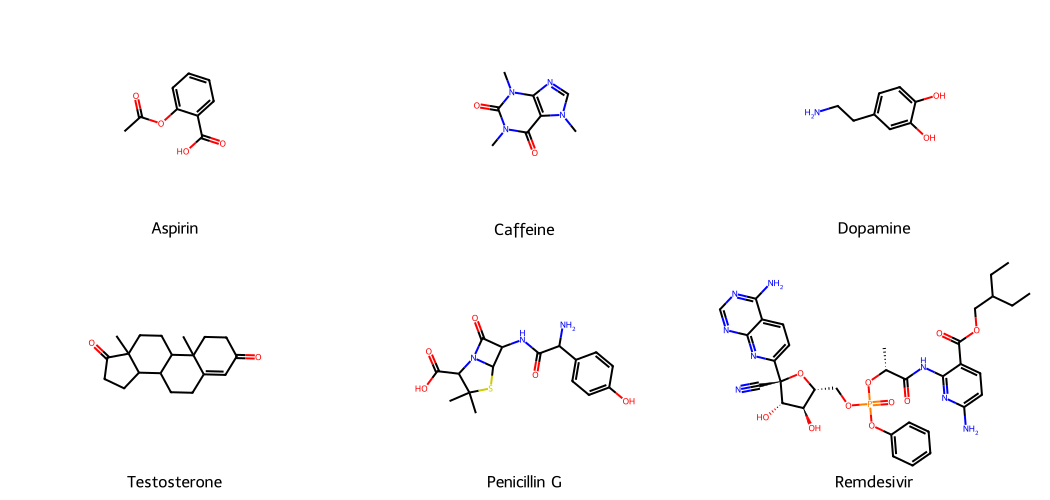

✅ Molecule visualization functions created


In [72]:
# 3.1 MOLECULE GRID VISUALIZATION
print("🖼️  Creating molecule grid visualization...")

subset_names = ['Aspirin', 'Caffeine', 'Dopamine', 'Testosterone', 'Penicillin G', 'Remdesivir']
subset_mols = [valid_molecules[name] for name in subset_names if name in valid_molecules]

# Create grid with enhanced styling
img = Draw.MolsToGridImage(
    subset_mols,
    molsPerRow=3,
    subImgSize=(350, 250),
    legends=subset_names,
    returnPNG=True,
    useSVG=False
)

# Save and display
with open("molecule_grid.png", "wb") as f:
    f.write(img.data)

print(f"✅ Created grid with {len(subset_mols)} molecules")
display(img)

# 3.2 FUNCTION TO CREATE HIGHLIGHTED MOLECULES
# Function to create highlighted molecule images
def create_highlighted_mol_image(mol, name, highlight_atoms=None, highlight_bonds=None):
    """Create a highlighted molecule image"""
    drawer = rdMolDraw2D.MolDraw2DCairo(400, 300)
    
    # Set drawing options (use available methods)
    drawer.drawOptions().setHighlightColour((0.8, 0.8, 0.2, 0.8))  # Yellow highlight
    
    # Draw with highlights
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightBonds=highlight_bonds)
    drawer.FinishDrawing()
    
    # Get PNG data
    png_data = drawer.GetDrawingText()
    return png_data

print("✅ Molecule visualization functions created")

## 4. SUBSTRUCTURE SEARCHING AND MOLECULAR SIMILARITY

Use SMARTS patterns to find pharmacophoric features and analyze molecular similarity using Morgan fingerprints.

In [73]:
# 4.1 SUBSTRUCTURE PATTERN MATCHING
print("🧩 Substructure pattern matching...")

# Define pharmacophore patterns
patterns = {
    'Benzene': ('c1ccccc1', 'Aromatic ring'),
    'Carboxylic_Acid': ('[CX3](=O)[OX2H1]', 'COOH group'),
    'Amine_Primary': ('[NX3;H2]', 'Primary amine'),
    'Amine_Secondary': ('[NX3;H1]', 'Secondary amine'),
    'Hydroxyl': ('[OX2H]', 'OH group'),
    'Ketone': ('[CX3]=O', 'Carbonyl group'),
}

# Compile SMARTS patterns
compiled_patterns = {}
for name, (smarts, description) in patterns.items():
    pattern_mol = Chem.MolFromSmarts(smarts)
    if pattern_mol:
        compiled_patterns[name] = (pattern_mol, description)

# Search for patterns in all molecules
substructure_results = []
for mol_name, mol in valid_molecules.items():
    matches = {}
    for pattern_name, (pattern_mol, description) in compiled_patterns.items():
        has_match = mol.HasSubstructMatch(pattern_mol)
        matches[pattern_name] = has_match
    substructure_results.append({'Molecule': mol_name, **matches})

# Create results dataframe
substructure_df = pd.DataFrame(substructure_results).set_index('Molecule')

print("📊 Substructure matching results:")
# Style the dataframe for better visualization
def style_substructure(val):
    return 'background-color: #4CAF50; color: white' if val else 'background-color: #f5f5f5'

styled_substructure = substructure_df.style.map(style_substructure)
display(styled_substructure)

# Summary statistics
pattern_counts = substructure_df.sum().sort_values(ascending=False)
print(f"\n📈 Pattern frequency across {len(substructure_df)} molecules:")
for pattern, count in pattern_counts.items():
    percentage = (count / len(substructure_df)) * 100
    print(f"  {pattern}: {int(count)} molecules ({percentage:.1f}%)")

🧩 Substructure pattern matching...
📊 Substructure matching results:


,Benzene,Carboxylic_Acid,Amine_Primary,Amine_Secondary,Hydroxyl,Ketone
Molecule,,,,,,
Aspirin,True,True,False,False,True,True
Ibuprofen,True,True,False,False,True,True
Naproxen,True,True,False,False,True,True
Paracetamol,True,False,False,True,True,True
Caffeine,False,False,False,False,False,False
Nicotine,False,False,False,False,False,False
Dopamine,True,False,True,False,True,False
Serotonin,True,False,True,False,True,False
Testosterone,False,False,False,False,False,True



📈 Pattern frequency across 14 molecules:
  Hydroxyl: 11 molecules (78.6%)
  Benzene: 9 molecules (64.3%)
  Ketone: 8 molecules (57.1%)
  Amine_Primary: 5 molecules (35.7%)
  Carboxylic_Acid: 4 molecules (28.6%)
  Amine_Secondary: 3 molecules (21.4%)


In [74]:
# Calculate properties for each conformer
conformer_props = []
for i, conf_id in enumerate(conformers):
    # Get conformer
    conf = flexible_mol.GetConformer(conf_id)

    # Calculate energy (if optimization succeeded)
    energy = energies[i] if i < len(energies) else None

    # Get conformer positions
    positions = conf.GetPositions()
    num_atoms = len(positions)

    conformer_props.append({
        'Conformer': i+1,
        'Energy': energy,
        'Num_Atoms': num_atoms
    })